In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\sanni bhuwad\OneDrive\Documents\GitHub\Infotact-project\AtmoSync\data\cleaned\Cleaned_Dataset_AirFreight.csv"
)

print("Shape:", df.shape)
df.head()

Shape: (257, 19)


,shipment_id,transport_mode,recorded_date,recorded_time,recorded_datetime,origin_location,destination_location,cargo_type,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days,spoilage_status
0,AIR1001,Air Freight,2026-06-25,05:40,2026-06-25 05:40:00,Kolkata Airport,Dubai Airport,Meat,1.1,34.2,2.5,91.1,42.6,0,0.0,0.0,27.3,5.0,At Risk
1,AIR0283,Air Freight,2026-06-23,11:10,2026-06-23 11:10:00,Bengaluru Airport,Doha Airport,Seafood,3.2,24.6,0.9,86.6,28.4,0,0.0,0.0,17.4,3.6,Fresh
2,AIR0237,Air Freight,2026-03-19,17:05,2026-03-19 17:05:00,Mumbai Airport,Frankfurt Airport,Meat,3.6,35.5,3.0,87.7,37.3,0,0.0,0.0,22.9,4.5,Fresh
3,AIR0829,Air Freight,2025-03-15,12:35,2025-03-15 12:35:00,Hyderabad Airport,Amsterdam Airport,Meat,1.6,39.4,0.7,84.4,29.1,0,0.0,0.0,13.9,5.2,Fresh
4,AIR0976,Air Freight,2026-01-20,03:15,2026-01-20 03:15:00,Chennai Airport,Dubai Airport,Fruits,4.1,35.7,5.6,77.3,35.0,0,0.0,0.0,16.2,10.9,Fresh


In [3]:
print("Columns:")
print(df.columns.tolist())

Columns:
['shipment_id', 'transport_mode', 'recorded_date', 'recorded_time', 'recorded_datetime', 'origin_location', 'destination_location', 'cargo_type', 'temperature_celsius', 'humidity_percentage', 'vibration_level', 'pressure_kpa', 'exposure_duration_hours', 'door_open_count', 'salinity_ppt', 'thermal_leakage_score', 'spoilage_risk_percent', 'remaining_shelf_life_days', 'spoilage_status']


In [4]:
print(df["remaining_shelf_life_days"].describe())

count    257.000000
mean      10.135409
std        8.409469
min        2.000000
25%        4.700000
50%        6.300000
75%       10.400000
max       29.700000
Name: remaining_shelf_life_days, dtype: float64


In [5]:
df["shelf_life_category"] = pd.cut(
    df["remaining_shelf_life_days"],
    bins=[-1, 2, 5, float("inf")],
    labels=["Critical", "At Risk", "Safe"]
)

print(df["shelf_life_category"].value_counts())

shelf_life_category
Safe        179
At Risk      77
Critical      1
Name: count, dtype: int64


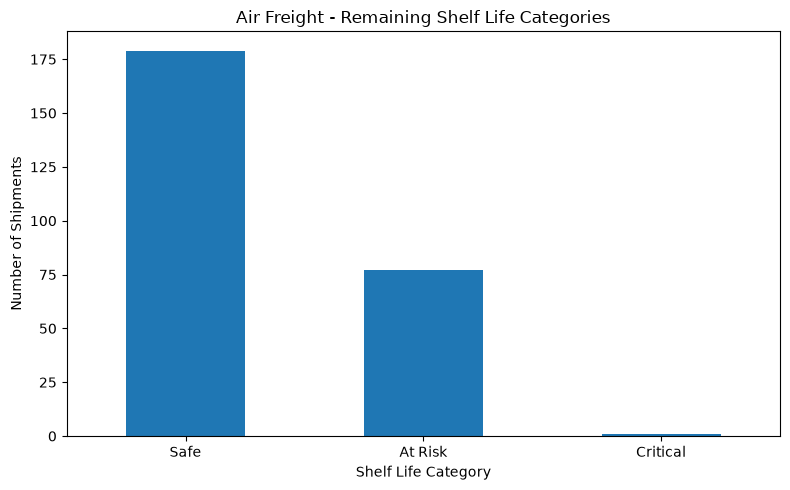

In [6]:
df["shelf_life_category"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Shelf Life Category")
plt.ylabel("Number of Shipments")
plt.title("Air Freight - Remaining Shelf Life Categories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
print(
    df[
        ["remaining_shelf_life_days", "shelf_life_category"]
    ].head(10)
)

   remaining_shelf_life_days shelf_life_category
0                        5.0             At Risk
1                        3.6             At Risk
2                        4.5             At Risk
3                        5.2                Safe
4                       10.9                Safe
5                        2.9             At Risk
6                        5.0             At Risk
7                        5.5                Safe
8                        4.2             At Risk
9                       10.6                Safe


In [8]:
print("\nShelf Life Summary:")
print(df["shelf_life_category"].value_counts())


Shelf Life Summary:
shelf_life_category
Safe        179
At Risk      77
Critical      1
Name: count, dtype: int64


In [9]:
critical = df[df["shelf_life_category"] == "Critical"]

print("Critical shipments:", len(critical))
critical.head()

Critical shipments: 1


,shipment_id,transport_mode,recorded_date,recorded_time,recorded_datetime,origin_location,destination_location,cargo_type,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days,spoilage_status,shelf_life_category
136,AIR0968,Air Freight,2024-06-30,19:45,2024-06-30 19:45:00,Chennai Airport,Frankfurt Airport,Seafood,-7.9,27.9,1.4,80.1,47.9,0,0.0,0.0,96.9,2.0,Spoiled,Critical
